# ShopSphere — power-aware A/B test analysis (M6)

One experiment shipped: **`free_shipping_threshold`** (Feb 15 – Apr 30 2026,
30,000 assignments per arm). Fixed-horizon frequentist analysis, α = 0.05
two-sided — the horizon was fixed by design, so no peeking corrections are
needed; that caveat matters and is stated rather than assumed.

Order of operations mirrors how a real experiment review should run:
**1)** validity (sample-ratio mismatch), **2)** the primary metric with
uncertainty, **3)** was the test even powered for what we saw, **4)** guardrail
(did the treatment buy conversions by destroying basket size?).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from config.db import get_engine

FIG = ROOT / 'reports' / 'figures'
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY = '#1f77b4', '#d62728', '#7f7f7f'

engine = get_engine()
ab = pd.read_sql(
    'SELECT variant, converted_flag, assigned_date, order_id '
    'FROM silver_ab_test_assignments', engine, parse_dates=['assigned_date'])
n = ab.groupby('variant').size()
conv = ab.groupby('variant')['converted_flag'].mean()
n_c, n_t = int(n['control']), int(n['treatment'])
p_c, p_t = float(conv['control']), float(conv['treatment'])
print(f'{len(ab):,} assignments | control {n_c:,} @ {p_c:.4f} | '
      f'treatment {n_t:,} @ {p_t:.4f}')

60,000 assignments | control 30,000 @ 0.0343 | treatment 30,000 @ 0.0395


## 1) Validity — sample ratio mismatch (SRM)

A 50/50 design that lands materially off 50/50 means broken randomization and
invalidates everything downstream. Chi-square goodness-of-fit against the
designed split.

In [2]:
chi2, srm_p = stats.chisquare([n_c, n_t])
print(f'SRM chi-square p = {srm_p:.4f} '
      f'({"OK — no mismatch" if srm_p > 0.001 else "FAIL — broken randomization"})')

SRM chi-square p = 1.0000 (OK — no mismatch)


## 2) Primary metric — conversion

Two-proportion z-test; absolute difference CI (unpooled Wald); relative lift
CI via the delta method on log risk-ratio.

absolute diff  +0.52pp  (95% CI +0.22 .. +0.82pp)
relative lift  +15.1%  (95% CI +6.0% .. +24.9%)
z = 3.36, p = 7.87e-04 -> significant at alpha=0.05


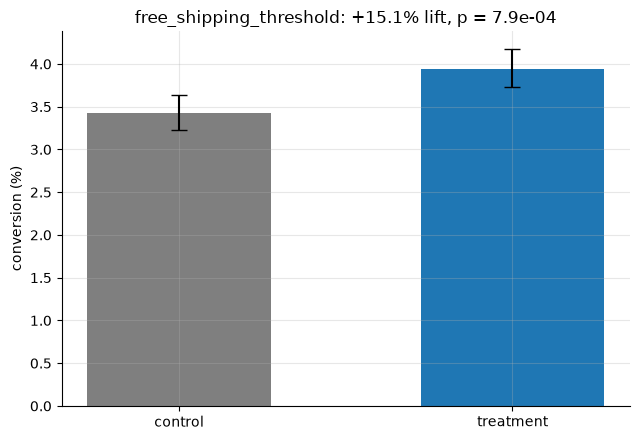

In [3]:
diff = p_t - p_c
p_pool = (n_c * p_c + n_t * p_t) / (n_c + n_t)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_c + 1 / n_t))
z = diff / se_pool
p_value = 2 * stats.norm.sf(abs(z))

se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
ci_diff = (diff - 1.96 * se_diff, diff + 1.96 * se_diff)

lift = p_t / p_c - 1
se_log_rr = np.sqrt((1 - p_c) / (n_c * p_c) + (1 - p_t) / (n_t * p_t))
ci_lift = (np.exp(np.log(p_t / p_c) - 1.96 * se_log_rr) - 1,
           np.exp(np.log(p_t / p_c) + 1.96 * se_log_rr) - 1)

print(f'absolute diff  {diff * 100:+.2f}pp  (95% CI {ci_diff[0] * 100:+.2f} .. '
      f'{ci_diff[1] * 100:+.2f}pp)')
print(f'relative lift  {lift:+.1%}  (95% CI {ci_lift[0]:+.1%} .. {ci_lift[1]:+.1%})')
print(f'z = {z:.2f}, p = {p_value:.2e} -> '
      f'{"significant at alpha=0.05" if p_value < 0.05 else "NOT significant"}')

def wilson(p, nn):
    z95 = 1.96
    den = 1 + z95**2 / nn
    center = (p + z95**2 / (2 * nn)) / den
    half = z95 * np.sqrt(p * (1 - p) / nn + z95**2 / (4 * nn**2)) / den
    return center - half, center + half

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for i, (label, pp, nn, color) in enumerate(
        [('control', p_c, n_c, GRAY), ('treatment', p_t, n_t, BLUE)]):
    lo, hi = wilson(pp, nn)
    ax.bar(label, pp * 100, color=color, width=0.55)
    ax.errorbar(i, pp * 100, yerr=[[(pp - lo) * 100], [(hi - pp) * 100]],
                color='black', capsize=6, fmt='none')
ax.set_ylabel('conversion (%)')
ax.set_title(f'free_shipping_threshold: {lift:+.1%} lift, p = {p_value:.1e}')
fig.tight_layout()
fig.savefig(FIG / 'ab_conversion_ci.png', bbox_inches='tight')
plt.show()

## 3) Power — was this test able to see what it claims to see?

Everything at α = 0.05 two-sided, 30,000 per arm, baseline = control rate.

MDE @80% power, n=30,000/arm, baseline 3.43%: +12.5% relative lift
achieved power for observed +15.1%: 91.9%


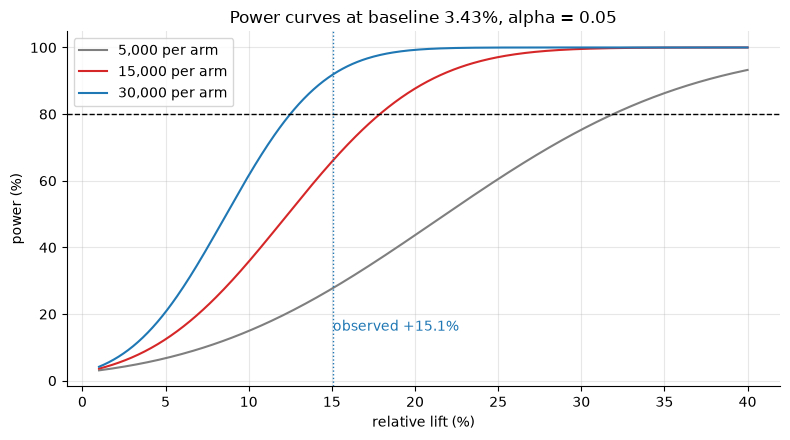

In [4]:
Z_A = stats.norm.ppf(0.975)

def power_two_prop(p1, rel_lift, n_per_arm):
    p2 = p1 * (1 + rel_lift)
    se = np.sqrt(p1 * (1 - p1) / n_per_arm + p2 * (1 - p2) / n_per_arm)
    return stats.norm.cdf(abs(p2 - p1) / se - Z_A)

# minimum detectable relative lift at 80% power for this design
grid = np.linspace(0.01, 0.40, 400)
powers_design = np.array([power_two_prop(p_c, g, n_c) for g in grid])
mde = grid[np.argmax(powers_design >= 0.8)]
achieved = power_two_prop(p_c, lift, n_c)
print(f'MDE @80% power, n={n_c:,}/arm, baseline {p_c:.2%}: {mde:+.1%} relative lift')
print(f'achieved power for observed {lift:+.1%}: {achieved:.1%}')

fig, ax = plt.subplots(figsize=(8, 4.5))
for nn, color in [(5000, GRAY), (15000, RED), (30000, BLUE)]:
    ax.plot(grid * 100, [power_two_prop(p_c, g, nn) * 100 for g in grid],
            color=color, label=f'{nn:,} per arm')
ax.axhline(80, ls='--', color='black', lw=1)
ax.axvline(lift * 100, ls=':', color=BLUE, lw=1)
ax.annotate(f'observed {lift:+.1%}', (lift * 100, 15), color=BLUE)
ax.set_xlabel('relative lift (%)')
ax.set_ylabel('power (%)')
ax.set_title(f'Power curves at baseline {p_c:.2%}, alpha = 0.05')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'ab_power_curve.png', bbox_inches='tight')
plt.show()

## 4) Guardrail — revenue per converted order

A free-shipping threshold can inflate conversion while shrinking baskets.
Welch t-test on completed-order revenue of converted assignments.

In [5]:
rev = pd.read_sql(
    "SELECT a.variant, r.order_revenue FROM silver_ab_test_assignments a "
    "JOIN gold_order_revenue r ON r.order_id = a.order_id "
    "WHERE a.converted_flag = 1 AND r.order_status = 'completed' "
    "AND r.order_revenue IS NOT NULL", engine)
rev['order_revenue'] = rev['order_revenue'].astype(float)
g = rev.groupby('variant')['order_revenue']
t_stat, t_p = stats.ttest_ind(
    rev.loc[rev.variant == 'treatment', 'order_revenue'],
    rev.loc[rev.variant == 'control', 'order_revenue'], equal_var=False)
print(g.agg(['count', 'mean', 'median']).round(2).to_string())
print(f'Welch t-test on order revenue: t = {t_stat:.2f}, p = {t_p:.3f} -> '
      f'{"basket size differs" if t_p < 0.05 else "no detectable basket-size change"}')
rev_per_assignment = (rev.groupby('variant')['order_revenue'].sum()
                      / n).rename('rev_per_assignment')
print(rev_per_assignment.round(4).to_string())

           count   mean  median
variant                        
control      923  97.36   57.49
treatment   1071  88.80   52.70
Welch t-test on order revenue: t = -1.80, p = 0.071 -> no detectable basket-size change
variant
control      2.9955
treatment    3.1703


## Validation — hard gates

Fails on execution if the experiment data or headline stats drift.

In [6]:
CALIBRATION_LIFT = 0.151  # docs/calibration_report.md, A/B relative lift

assert len(ab) == 60_000, len(ab)
assert srm_p > 0.001, 'SRM detected — randomization broken'
assert abs(lift - CALIBRATION_LIFT) < 0.005, (lift, CALIBRATION_LIFT)
assert p_value < 0.05, 'primary metric not significant'
assert ci_lift[0] > 0, 'lift CI includes zero'
assert achieved > 0.8, 'test underpowered for observed effect'

print(f'assignments        {len(ab):,}')
print(f'SRM p              {srm_p:.4f}')
print(f'lift               {lift:+.3%} (calibration {CALIBRATION_LIFT:+.1%})')
print(f'p-value            {p_value:.2e} | achieved power {achieved:.1%}')
print(f'MDE @80%           {mde:+.1%}')
print('figures ->', sorted(p.name for p in FIG.glob('ab_*.png')))

assignments        60,000
SRM p              1.0000
lift               +15.063% (calibration +15.1%)
p-value            7.87e-04 | achieved power 91.9%
MDE @80%           +12.5%
figures -> ['ab_conversion_ci.png', 'ab_power_curve.png']
